In [ ]:
!git clone https://github.com/Nadim0403/Data_DL.git

Cloning into 'Data_DL'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 24 (delta 1), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (24/24), 1.04 MiB | 3.44 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
%matplotlib inline

# Fully connected neural network classifier

This code shows a simple fully connected neural network (also called Multi-Layer Perceptron). Look at the structure of the architecture and try to follow the size of the tensors at each step of the forward function.

In [ ]:
import torch.nn as nn

# Define the model
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, num_classes)

        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(32)
        self.bn4 = nn.BatchNorm1d(num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Layer 1
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Layer 2
        out = self.fc2(out)
        out = self.bn2(out)
        out = self.relu(out)

        # Layer 3
        out = self.fc3(out)
        out = self.bn3(out)
        out = self.relu(out)

        # Layer 4
        out = self.fc4(out)
        out = self.bn4(out)
        out = self.relu(out)

        # Output
        out = nn.functional.softmax(out, dim=1)

        return out

## Dataset
The Pima Indians Diabetes Dataset involves predicting the onset of diabetes within 5 years in Pima Indians given medical details.

It is a binary (2-class) classification problem. The number of observations for each class is not balanced. There are 768 observations with 8 input variables and 1 output variable. Missing values are believed to be encoded with zero values. The variable names are as follows:

* Number of times pregnant.
* Plasma glucose concentration a 2 hours in an oral glucose tolerance test.
* Diastolic blood pressure (mm Hg).
* Triceps skinfold thickness (mm).
* 2-Hour serum insulin (mu U/ml).
* Body mass index (weight in kg/(height in m)^2).
* Diabetes pedigree function.
* Age (years).
* Class variable (0 or 1).


In [ ]:
from torch.utils.data import Dataset
import torch
import numpy as np
from numpy import genfromtxt

class DiabetesDataset(Dataset):
    def __init__(self, file_path):
            # load csv file
            data = genfromtxt(file_path, delimiter=',')
            # get the features and labels
            self.features = np.array(data[:, :-1])

            # transform the integer labels to one-hot encoding https://stackoverflow.com/a/37323404/2562693
            raw_labels = np.array(data[:, -1]).astype(int)
            n_values = np.max(raw_labels).astype(int)+1
            self.labels = np.eye(n_values)[raw_labels]

            # Transform to torch tensor
            self.features = torch.tensor(self.features, dtype=torch.float32)
            self.labels = torch.tensor(self.labels, dtype=torch.float32)

    def __len__(self):
        # get the length of the dataset
        return self.features.shape[0]

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


**Task 1:** Compute the accuracy from the trained model. How does the neural network performs?

Note: The baseline performance of predicting the most prevalent class is a classification accuracy of approximately 65%. Top results achieve a classification accuracy of approximately 77%.

**Task 2:** Update the code for training on the `seeds_dataset_test.csv` and `seeds_dataset_test.csv` dataset

Note: The Seeds Dataset involves predicting whether what type a given wheat seed is. It is a multi class (3-class) classification problem. It has 210 instances of data involving 3 types of wheat seeds. The first 7 columns represent the features of the seed types, while the last column contains the label.

The baseline performance of predicting the most prevalent class is a classification accuracy of approximately 95%.

Epoch [2/500], Loss: 0.6328
Epoch [4/500], Loss: 0.6122
Epoch [6/500], Loss: 0.6085
Epoch [8/500], Loss: 0.5960
Epoch [10/500], Loss: 0.5891
Epoch [12/500], Loss: 0.5830
Epoch [14/500], Loss: 0.5778
Epoch [16/500], Loss: 0.5802
Epoch [18/500], Loss: 0.5814
Epoch [20/500], Loss: 0.5755
Epoch [22/500], Loss: 0.5717
Epoch [24/500], Loss: 0.5731
Epoch [26/500], Loss: 0.5723
Epoch [28/500], Loss: 0.5704
Epoch [30/500], Loss: 0.5654
Epoch [32/500], Loss: 0.5647
Epoch [34/500], Loss: 0.5629
Epoch [36/500], Loss: 0.5657
Epoch [38/500], Loss: 0.5653
Epoch [40/500], Loss: 0.5595
Epoch [42/500], Loss: 0.5641
Epoch [44/500], Loss: 0.5554
Epoch [46/500], Loss: 0.5549
Epoch [48/500], Loss: 0.5623
Epoch [50/500], Loss: 0.5491
Epoch [52/500], Loss: 0.5490
Epoch [54/500], Loss: 0.5536
Epoch [56/500], Loss: 0.5514
Epoch [58/500], Loss: 0.5516
Epoch [60/500], Loss: 0.5491
Epoch [62/500], Loss: 0.5528
Epoch [64/500], Loss: 0.5515
Epoch [66/500], Loss: 0.5462
Epoch [68/500], Loss: 0.5485
Epoch [70/500], Lo

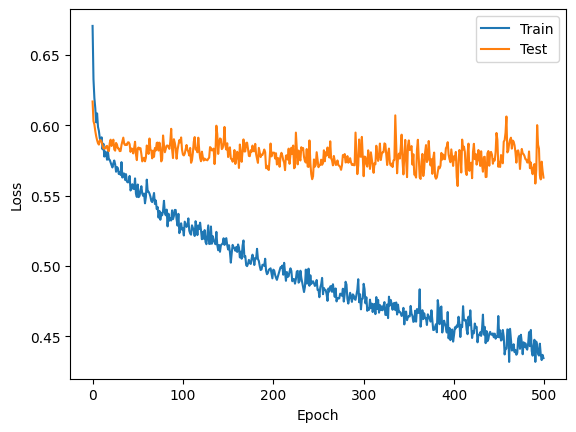

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# data loader
training_dataset = DiabetesDataset("Data_DL/data_MLP/data/pima-indians-diabetes_train.csv")
testing_dataset  = DiabetesDataset("Data_DL/data_MLP/data/pima-indians-diabetes_test.csv")
# training_dataset = DiabetesDataset("Data_DL/data_MLP/data/seeds_dataset_train.csv")
# testing_dataset  = DiabetesDataset("Data_DL/data_MLP/data/seeds_dataset_test.csv")

test_loader = DataLoader(testing_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(training_dataset, batch_size=128, shuffle=True)

model = MLP(8, 2)

# Define the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

# Train the model
# Track the losses at each epoch
losses = []
test_losses = []
num_epochs = 500
for epoch in range(num_epochs):
    running_loss = 0
    counter = 0
    for i, (features, labels) in enumerate(train_loader):
        optimizer.zero_grad()

        # Forward pass
        outputs = model.forward(features)
        loss = loss_fn(outputs, labels)

        # Backward and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        counter += 1

    # Save the loss value at this epoch
    losses.append(running_loss/counter)

    if (epoch + 1) % 2 == 0:
        # Print the loss value at the end of each epoch
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss/counter:.4f}')

    # Test the model
    with torch.no_grad():
        running_loss = 0
        counter = 0
        for features, labels in test_loader:
            outputs = model.forward(features)
            test_loss = loss_fn(outputs, labels)
            running_loss += test_loss.item()
            counter += 1
        test_losses.append(running_loss/counter)

# Plot the loss curve
plt.plot(losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.gcf().set_facecolor('white')
#plt.savefig('loss_curve.png')
plt.show()

In [ ]:
# Compute the accuracy of the predictions on the test set:
prediction = []
ground_truth = []
with torch.no_grad():
    for features, labels in test_loader:
        print(labels.shape[0])
        for i in range(labels.shape[0]):
            ground_truth.append(labels[i, 0].item())
        outputs = model(features)
        for i in range(outputs.shape[0]):
            if outputs[i, 0].item() > 0.5:
                prediction.append(1.0)
            else:
                prediction.append(0.0)

print(prediction)
print(ground_truth)

# Compute the accuracy (https://developers.google.com/machine-learning/crash-course/classification/accuracy)
correct = 0
total = 0
for i in range(len(prediction)):
    if prediction[i] == ground_truth[i]:
        correct += 1
    total += 1
accuracy = correct / total
print(f'Accuracy of the network on the test set: {accuracy * 100}%')
